Found 1 different disease classes.


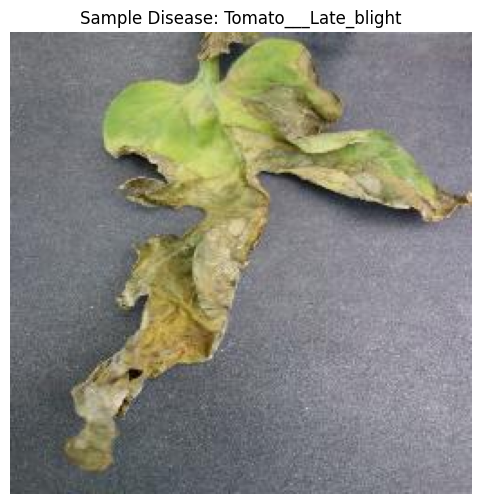

In [ ]:
import os
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

# Resolve the image folder robustly no matter where the notebook runs from
base_dir = Path.cwd()
candidates = [
    base_dir / 'data' / 'images',
    base_dir.parent / 'data' / 'images',
    Path('../data/images').resolve(),
]
image_dir = next((p for p in candidates if p.exists()), candidates[0])

# Get the names of all disease folders
# Ignore hidden/system files such as .DS_Store
class_folders = [entry.name for entry in os.scandir(image_dir) if entry.is_dir()]
print(f"Found {len(class_folders)} different disease classes.")

# Pick the first disease class and the first valid image inside it
first_disease = class_folders[0]
first_disease_dir = image_dir / first_disease
first_image_name = next(
    (
        entry.name
        for entry in os.scandir(first_disease_dir)
        if entry.is_file() and entry.name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'))
    ),
    None,
)

if first_image_name is None:
    raise FileNotFoundError(f"No image files found in {first_disease_dir}")

image_path = first_disease_dir / first_image_name

# Read and display the image
img = cv2.imread(str(image_path))
if img is None:
    raise FileNotFoundError(f"Could not read image: {image_path}")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Fix colors

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Sample Disease: {first_disease}")
plt.axis('off')
plt.show()
